# MIG Quant Competition — Strategy Development

This notebook shows you how to:
1. Build and iterate on a strategy using the `get_actions` interface.
2. Test with backtester locally to get PnL, Sharpe, and Max Drawdown.
3. Inspect portfolio behaviour before submitting.

### Creating an Algorithm

Guides / other resources:

- [Kaggle asset trading guide](https://www.kaggle.com/code/shtrausslearning/building-an-asset-trading-strategy)
- [Kaggle simple momentum trader](https://www.kaggle.com/code/amirmotefaker/algorithmic-trading)
- [Kaggle Decision Trees for trading](https://www.kaggle.com/code/sndorburian/decision-tree-for-trading-using-python)

Less Relevant:
- [Kaggle Features Hierarchical clustering](https://www.kaggle.com/code/apolitano20/jane-street-features-hierarchical-clustering/notebook)
- [Optiver intro to financial concepts](https://www.kaggle.com/code/jiashenliu/introduction-to-financial-concepts-and-data)

In general there are a few steps to creating a trading algorithm:
1. **Understanding and Exploring your data** — get to know what data you're given and find statistical or other properties about it
2. **Feature/signal creation** — create signals from the data (rolling average, correlation, etc.) — this is where most of the secret sauce is
3. **Feature selection + model creation** — decide what features to include and whether to use a machine-learning or rules-based model
4. **Testing** — test your model to see how it performed; avoid "data leakage" (trading on a day using future information)

Iterate steps 2–4 to refine and improve your model!

### Different types of models
- ML type (supervised vs unsupervised)
- Decision Trees (rule-based ML approach) — e.g. XGBoost
- Rule-based (hand-coded)

## Algorithm Input and Output

The algorithm takes in data similar to `dev_data_30.csv`.

The output should be a **NumPy array of size S×D** where S = number of stocks (alphabetical order) and D = number of days.  
For example, with stocks A and B over 5 days:

```python
[[0, 3, 0, -1, -5],   # trades for stock A
 [1, 5, 0, -6,  3]]  # trades for stock B
```

Positive values = buy shares; negative values = sell or short shares.

To save your output array:

```python
import numpy as np

output = np.array([[...],
                   [...],
                   ...])

np.save('output.npy', output)
```

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.insert(0, '..')
from backtester import Backtester

plt.style.use('dark_background')
print('Imports OK')

Imports OK


## 1. Load data and build the prices matrix

In [2]:
df = pd.read_csv('../dev_data_30.csv', parse_dates=['Date'], date_format='%m/%d/%y', thousands=',')

prices_df = df.pivot(index='Ticker', columns='Date', values='Open').sort_index()
prices_df = prices_df.ffill(axis=1).dropna(axis=1)

prices = prices_df.values   # shape: (num_stocks, num_days)
dates  = prices_df.columns  # DatetimeIndex
tickers = prices_df.index.tolist()

print('Prices matrix:', prices.shape)
print('Tickers:', tickers)

# Multi-index view for exploration (complement to the pivot above)
df_explore = pd.read_csv('../dev_data_30.csv', parse_dates=['Date'], date_format='%m/%d/%y', thousands=',')
df_explore.set_index(["Ticker", "Date"], inplace=True)

# Show the MultiIndex structure
df_explore.index

Prices matrix: (30, 1006)
Tickers: ['A', 'AA', 'AB', 'AC', 'AD', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


MultiIndex([( 'A', '2017-03-15'),
            ( 'A', '2017-03-16'),
            ( 'A', '2017-03-17'),
            ( 'A', '2017-03-20'),
            ( 'A', '2017-03-21'),
            ( 'A', '2017-03-22'),
            ( 'A', '2017-03-23'),
            ( 'A', '2017-03-24'),
            ( 'A', '2017-03-27'),
            ( 'A', '2017-03-28'),
            ...
            ('AD', '2021-03-01'),
            ('AD', '2021-03-02'),
            ('AD', '2021-03-03'),
            ('AD', '2021-03-04'),
            ('AD', '2021-03-05'),
            ('AD', '2021-03-08'),
            ('AD', '2021-03-09'),
            ('AD', '2021-03-10'),
            ('AD', '2021-03-11'),
            ('AD', '2021-03-12')],
           names=['Ticker', 'Date'], length=30180)

## 1.5 Explore the raw DataFrame

Before building a strategy, it helps to understand the raw DataFrame structure. `data_exploration.ipynb` walkthrough.

## 2. The Backtester

This is a copy of the server-side `Backtester` class so you can run it locally.

In [3]:
def backtest(strategy_fn, prices, cash=25_000):
    """Run strategy_fn on prices and return port_values + pnl."""
    actions = strategy_fn(prices)
    bt = Backtester(prices, actions, cash=cash)
    port_values, pnl = bt.eval_actions()
    if port_values is None:
        return None
    return {
        'port_values': np.array(port_values),
        'pnl': pnl,
    }

print('Backtester ready')

Backtester ready


## 3. Write your strategy

Edit the `get_actions` function below. The interface is identical to what the server expects.

In [4]:
# NOTE: that we don't use future price data to make trades in the past!
# This is to prevent "look-ahead bias" which is a common mistake in algorithmic trading, and will result in a score of 0 in the competition
# TODO: have a way to track your positions (short/long positions), your cash balance, adn your portfolio value
# recall the restrictions in the docs that you cannot buy a share if you don't have enough cash
# and you can't have your debt exceed the value of your cash and long positions
# "debt" in our case is really just the negative value of our short positions


def get_actions(prices: np.ndarray) -> np.ndarray:
    """
    5 / 20-day moving-average crossover — starter template.

    prices : np.ndarray  shape (num_stocks, num_days)  Open price
    returns: np.ndarray  shape (num_stocks, num_days)  shares to trade
    """
    num_stocks, num_days = prices.shape
    actions = np.zeros_like(prices)

    short_window, long_window = 5, 20

    for i in range(num_stocks):
        position = 0
        for t in range(long_window, num_days):
            short_ma = prices[i, t - short_window : t].mean()
            long_ma  = prices[i, t - long_window  : t].mean()

            if short_ma > long_ma and position == 0:
                actions[i, t] = 1
                position = 1
            elif short_ma <= long_ma and position == 1:
                actions[i, t] = -1
                position = 0

    return actions

## 3b. Stat Arb Strategy — Cointegration-Based

**Idea**: Use pre-2020 data (first 705 days) to fit OLS hedge ratios for each stock against all others. If the spread (stock − basket) is stationary (ADF p < 0.05), trade mean reversion on the z-score.

**Signal logic**:
- z > entry_z → short the stock, long top-3 basket constituents
- z < −entry_z → long the stock, short top-3 basket constituents
- |z| < exit_z → close the signal (both target and basket legs)

**Optimal parameters found via sweep** (accounting for 0.1% fees, 100-share limit):
- `entry_z = 1.75`, `exit_z = 0.4`
- `$450 per signal`, max 10 concurrent signals
- Net PnL ≈ $6,040 on dev_data_30

In [5]:
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------------------------
# Fit cointegration models on pre-2020 data
# ---------------------------------------------------------------------------
SPLIT = 705  # last day of 2019 in the prices matrix
train_prices = prices[:, :SPLIT]
num_stocks_all = prices.shape[0]

ENTRY_Z = 1.75
EXIT_Z = 0.4
DOLLAR_PER_SIGNAL = 450
MAX_SIGNALS = 10
POS_LIMIT = 100

coint_models = {}
for i in range(num_stocks_all):
    y = train_prices[i]
    X = np.delete(train_prices, i, axis=0).T
    reg = LinearRegression().fit(X, y)
    spread_train = y - reg.predict(X)
    adf_pval = adfuller(spread_train, maxlag=20, autolag='AIC')[1]
    weight_pairs = sorted(
        zip([j for j in range(num_stocks_all) if j != i], reg.coef_),
        key=lambda x: abs(x[1]), reverse=True
    )
    coint_models[i] = {
        'coef': reg.coef_, 'intercept': reg.intercept_,
        'top3': weight_pairs[:3],
        'mean': spread_train.mean(), 'std': spread_train.std(),
        'adf_pval': adf_pval,
    }

qualifying = [i for i in range(num_stocks_all) if coint_models[i]['adf_pval'] < 0.05]
print(f"Qualifying stocks (ADF p < 0.05): {len(qualifying)} / {num_stocks_all}")


def get_actions_statarb(prices: np.ndarray) -> np.ndarray:
    num_stocks, num_days = prices.shape
    actions = np.zeros((num_stocks, num_days))
    active_signals = {}  # target_idx -> {stock_idx: shares}

    for day in range(SPLIT, num_days):
        # Compute z-scores
        z_scores = {}
        for i in qualifying:
            info = coint_models[i]
            other_prices = np.delete(prices[:, day], i)
            basket_val = info['coef'] @ other_prices + info['intercept']
            spread = prices[i, day] - basket_val
            z_scores[i] = (spread - info['mean']) / info['std']

        # Close reverted signals
        for target_i in [t for t in active_signals if abs(z_scores.get(t, 0)) < EXIT_Z]:
            for s, shares in active_signals.pop(target_i).items():
                actions[s, day] -= shares

        # Open new signals (strongest first)
        if len(active_signals) < MAX_SIGNALS:
            candidates = sorted(
                [(abs(z_scores[i]), i, z_scores[i]) for i in qualifying if i not in active_signals],
                reverse=True
            )
            for abs_z, i, z in candidates:
                if len(active_signals) >= MAX_SIGNALS or abs_z < ENTRY_Z:
                    break
                price_i = prices[i, day]
                target_shares = min(int(DOLLAR_PER_SIGNAL / price_i), POS_LIMIT)
                if target_shares == 0:
                    continue

                held = {}
                direction = -1 if z > ENTRY_Z else 1  # short if spread high, long if low
                held[i] = direction * target_shares
                for bidx, w in coint_models[i]['top3']:
                    bs = min(max(int(target_shares * abs(w) * price_i / prices[bidx, day]), 1), POS_LIMIT)
                    basket_dir = -direction if w > 0 else direction
                    held[bidx] = held.get(bidx, 0) + basket_dir * bs

                # Check position limits
                ok = all(
                    abs(sum(sig.get(s, 0) for sig in active_signals.values()) + sh + actions[s, day]) <= POS_LIMIT
                    for s, sh in held.items()
                )
                if ok:
                    for s, sh in held.items():
                        actions[s, day] += sh
                    active_signals[i] = held

    return actions

print("Strategy defined.")

Qualifying stocks (ADF p < 0.05): 30 / 30
Strategy defined.


Final portfolio value: 31075.66
PnL: 6075.66
Raw PnL:  $6,075.66
Fees:     $36.21
Net PnL:  $6,039.45
Trades:   100


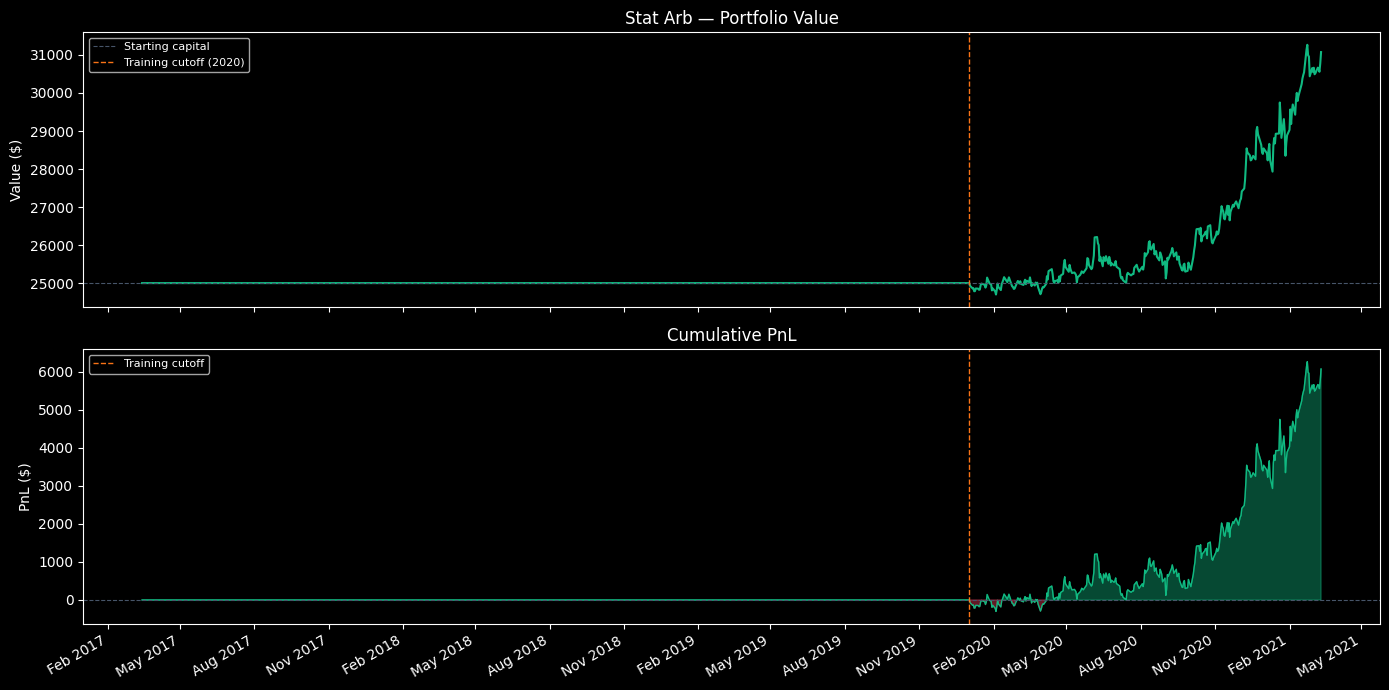

In [6]:
# Backtest the stat arb strategy
results_arb = backtest(get_actions_statarb, prices)

if results_arb:
    # Account for fees
    acts = get_actions_statarb(prices)
    total_fees = np.sum(np.abs(acts) * prices * 0.001)
    n_trades = np.count_nonzero(acts)
    print(f"Raw PnL:  ${results_arb['pnl']:,.2f}")
    print(f"Fees:     ${total_fees:,.2f}")
    print(f"Net PnL:  ${results_arb['pnl'] - total_fees:,.2f}")
    print(f"Trades:   {n_trades}")

    pv = results_arb['port_values']
    pnl_curve = pv - 25_000

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    axes[0].plot(dates, pv, color='#10b981', linewidth=1.5)
    axes[0].axhline(25_000, color='#475569', linewidth=0.8, linestyle='--', label='Starting capital')
    axes[0].axvline(dates[SPLIT], color='#f97316', linewidth=1, linestyle='--', label='Training cutoff (2020)')
    axes[0].set_title('Stat Arb — Portfolio Value')
    axes[0].set_ylabel('Value ($)')
    axes[0].legend(fontsize=8)

    pos_mask = pnl_curve >= 0
    axes[1].fill_between(dates, pnl_curve, where=pos_mask, color='#10b981', alpha=0.4)
    axes[1].fill_between(dates, pnl_curve, where=~pos_mask, color='#f43f5e', alpha=0.4)
    axes[1].plot(dates, pnl_curve, color='#10b981', linewidth=1)
    axes[1].axhline(0, color='#475569', linewidth=0.8, linestyle='--')
    axes[1].axvline(dates[SPLIT], color='#f97316', linewidth=1, linestyle='--', label='Training cutoff')
    axes[1].set_title('Cumulative PnL')
    axes[1].set_ylabel('PnL ($)')
    axes[1].legend(fontsize=8)
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Backtest failed.')

## 4. Run the backtest

In [7]:
results = backtest(get_actions, prices)

if results:
    print(f"PnL: ${results['pnl']:,.2f}")
else:
    print('Backtest failed — check your strategy for errors.')

Final portfolio value: 26240.01
PnL: 1240.01
PnL: $1,240.01


## 5. Visualise portfolio value

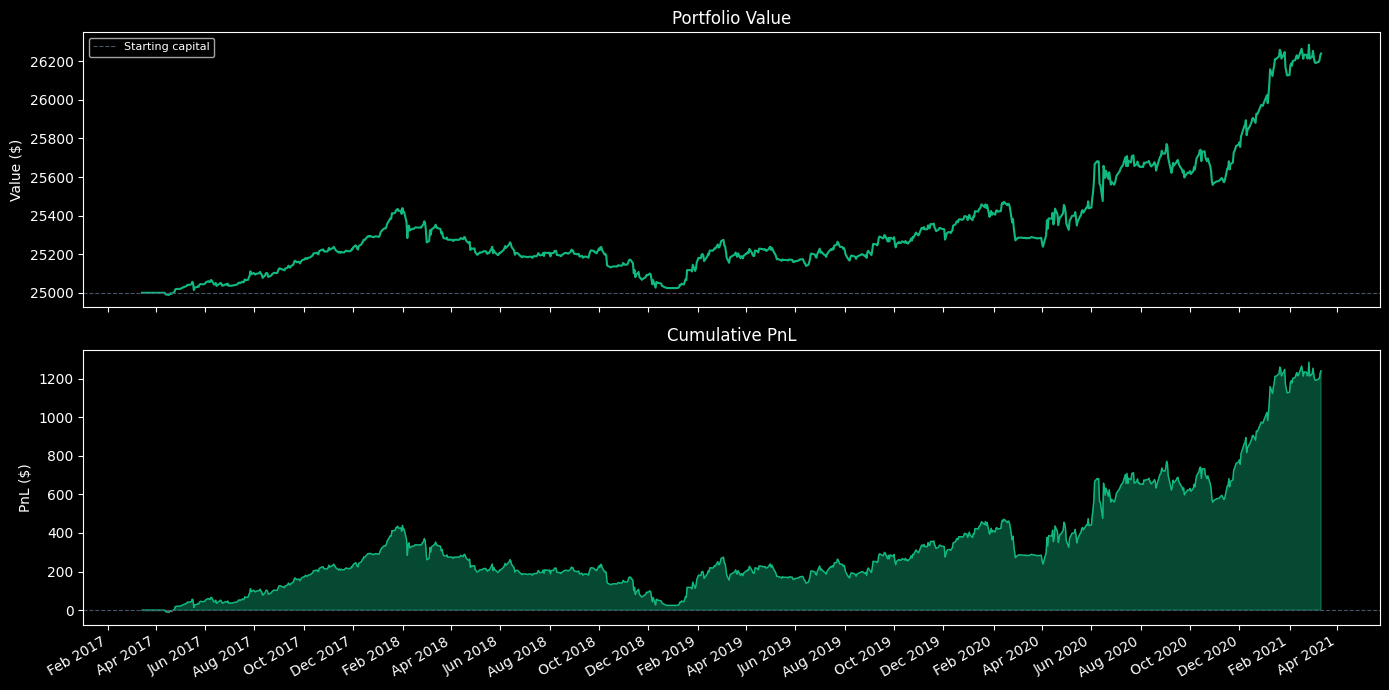

In [8]:
if results:
    pv   = results['port_values']
    pnl  = pv - 25_000

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # Portfolio value
    axes[0].plot(dates, pv, color='#10b981', linewidth=1.5)
    axes[0].axhline(25_000, color='#475569', linewidth=0.8, linestyle='--', label='Starting capital')
    axes[0].set_title('Portfolio Value')
    axes[0].set_ylabel('Value ($)')
    axes[0].legend(fontsize=8)

    # Cumulative PnL
    pos_mask = pnl >= 0
    axes[1].fill_between(dates, pnl, where=pos_mask,  color='#10b981', alpha=0.4)
    axes[1].fill_between(dates, pnl, where=~pos_mask, color='#f43f5e', alpha=0.4)
    axes[1].plot(dates, pnl, color='#10b981', linewidth=1)
    axes[1].axhline(0, color='#475569', linewidth=0.8, linestyle='--')
    axes[1].set_title('Cumulative PnL')
    axes[1].set_ylabel('PnL ($)')
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=30, ha='right')

    plt.tight_layout()
    plt.show()

## 7. Per-stock contribution to PnL

Which stocks drove your returns?

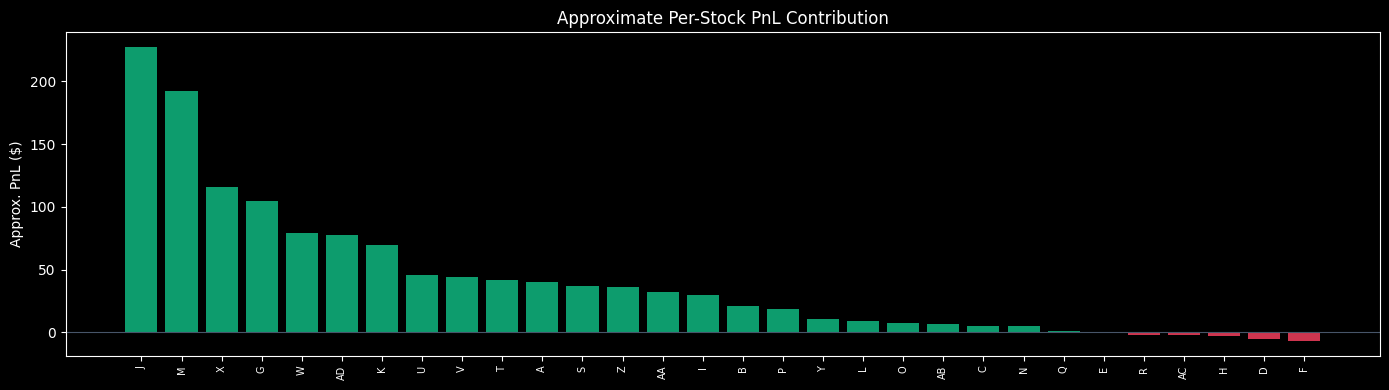

In [9]:
# Rough per-stock PnL estimate: sum of (action × price × sign)
actions_out = get_actions(prices)
actions_rounded = np.round(actions_out).astype(int)

# Approximate realised P&L per stock (ignores FIFO short accounting)
trade_pnl = np.zeros(len(tickers))
for s in range(len(tickers)):
    trade_pnl[s] = -np.sum(actions_rounded[s] * prices[s])

# Add mark-to-market of any remaining positions
final_position = actions_rounded.sum(axis=1)
mtm = final_position * prices[:, -1]
approx_pnl = trade_pnl + mtm

pnl_df = pd.Series(approx_pnl, index=tickers).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#10b981' if v >= 0 else '#f43f5e' for v in pnl_df.values]
ax.bar(pnl_df.index, pnl_df.values, color=colors, alpha=0.85)
ax.axhline(0, color='#475569', linewidth=0.8)
ax.set_title('Approximate Per-Stock PnL Contribution')
ax.set_ylabel('Approx. PnL ($)')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

## 8. Improve & iterate

Some ideas to try:

- **Change the MA windows** — try 10/50, or EMA instead of SMA.
- **Add position sizing** — trade more shares when the signal is stronger.
- **Use RSI or Bollinger Bands** via `ta-lib`.
- **Cross-sectional momentum** — rank stocks by recent return and go long top N, short bottom N.
- **Mean reversion** — trade against recent moves instead of following them.
- **Risk controls** — cap total exposure, stop-out losing positions.

Once you are happy with local results, copy your `get_actions` function into a `.py` file and submit on the **Submit** page.

In [10]:
def compare_strategies(strategies: dict, prices, cash=25_000):
    """strategies: {name: get_actions_fn}"""
    rows = []
    for name, fn in strategies.items():
        r = backtest(fn, prices, cash=cash)
        rows.append({
            'Strategy': name,
            'PnL ($)': f"{r['pnl']:,.2f}" if r else 'FAILED',
        })
    return pd.DataFrame(rows).set_index('Strategy')


def ma_crossover(short_w, long_w):
    def fn(prices):
        num_stocks, num_days = prices.shape
        actions = np.zeros_like(prices)
        for i in range(num_stocks):
            pos = 0
            for t in range(long_w, num_days):
                sm = prices[i, t - short_w : t].mean()
                lm = prices[i, t - long_w  : t].mean()
                if sm > lm and pos == 0:
                    actions[i, t] = 1; pos = 1
                elif sm <= lm and pos == 1:
                    actions[i, t] = -1; pos = 0
        return actions
    fn.__name__ = f'MA({short_w}/{long_w})'
    return fn


strats = {
    'MA(5/20)':  ma_crossover(5, 20),
    'MA(10/50)': ma_crossover(10, 50),
    'MA(3/10)':  ma_crossover(3, 10),
}

compare_strategies(strats, prices)

Final portfolio value: 26240.01
PnL: 1240.01
Final portfolio value: 26231.54
PnL: 1231.54
Final portfolio value: 26410.76
PnL: 1410.76


,PnL ($)
Strategy,
MA(5/20),"1,240.01"
MA(10/50),"1,231.54"
MA(3/10),"1,410.76"


## 9. ETF Stat Arb — Backtest & Visualization

Run the ETF stat arb strategy (`strategy_etf_arb.py`) with the best parameters from grid search:
- `entry_threshold = 0.5` (fixed dollar spread)
- `max_position = 20` shares per signal
- `hedge_ratio = 0.5` (half-hedge basket exposure)
- Net PnL ≈ $9,867 on dev_data_30

In [11]:
sys.path.insert(0, '..')
from strategy_etf_arb import get_actions as get_actions_etf

# --- Run with best params ---
ENTRY_THRESH = 0.5
MAX_POS = 20
HEDGE = 0.5

acts_etf = get_actions_etf(prices, entry_threshold=ENTRY_THRESH,
                            max_position=MAX_POS, hedge_ratio=HEDGE)

# Backtest
bt_etf = Backtester(prices, acts_etf, cash=25_000)
port_values_etf, pnl_etf = bt_etf.eval_actions()

fees_etf = np.sum(np.abs(acts_etf) * prices * 0.001)
n_trades_etf = np.count_nonzero(acts_etf)

print(f"Raw PnL:    ${pnl_etf:,.2f}")
print(f"Fees (0.1%): ${fees_etf:,.2f}")
print(f"Net PnL:    ${pnl_etf - fees_etf:,.2f}")
print(f"Trades:     {n_trades_etf}")
print(f"Max Drawdown: ${25_000 - min(port_values_etf):,.2f}")

Final portfolio value: 38412.26
PnL: 13412.26
Raw PnL:    $13,412.26
Fees (0.1%): $3,544.90
Net PnL:    $9,867.36
Trades:     4314
Max Drawdown: $0.00


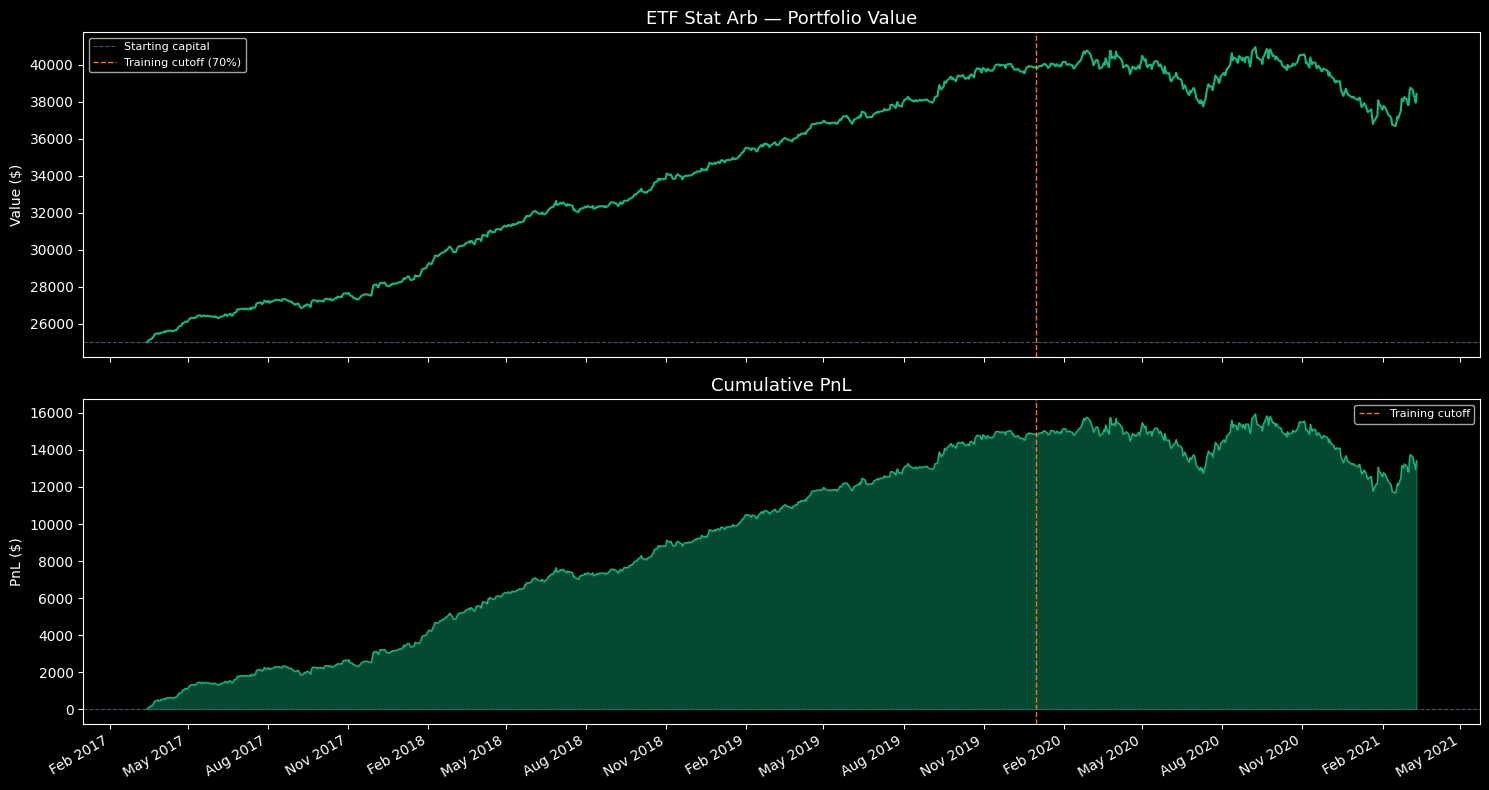

In [12]:
# ---------------------------------------------------------------------------
# Plot 1: Portfolio value & cumulative PnL
# ---------------------------------------------------------------------------
pv_etf = np.array(port_values_etf)
pnl_curve_etf = pv_etf - 25_000
train_end = int(len(dates) * 0.70)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Portfolio value
axes[0].plot(dates, pv_etf, color='#10b981', linewidth=1.5)
axes[0].axhline(25_000, color='#475569', linewidth=0.8, linestyle='--', label='Starting capital')
axes[0].axvline(dates[train_end], color='#f97316', linewidth=1, linestyle='--', label='Training cutoff (70%)')
axes[0].set_title('ETF Stat Arb — Portfolio Value', fontsize=13)
axes[0].set_ylabel('Value ($)')
axes[0].legend(fontsize=8)

# Cumulative PnL
pos_mask = pnl_curve_etf >= 0
axes[1].fill_between(dates, pnl_curve_etf, where=pos_mask, color='#10b981', alpha=0.4)
axes[1].fill_between(dates, pnl_curve_etf, where=~pos_mask, color='#f43f5e', alpha=0.4)
axes[1].plot(dates, pnl_curve_etf, color='#10b981', linewidth=1)
axes[1].axhline(0, color='#475569', linewidth=0.8, linestyle='--')
axes[1].axvline(dates[train_end], color='#f97316', linewidth=1, linestyle='--', label='Training cutoff')
axes[1].set_title('Cumulative PnL', fontsize=13)
axes[1].set_ylabel('PnL ($)')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

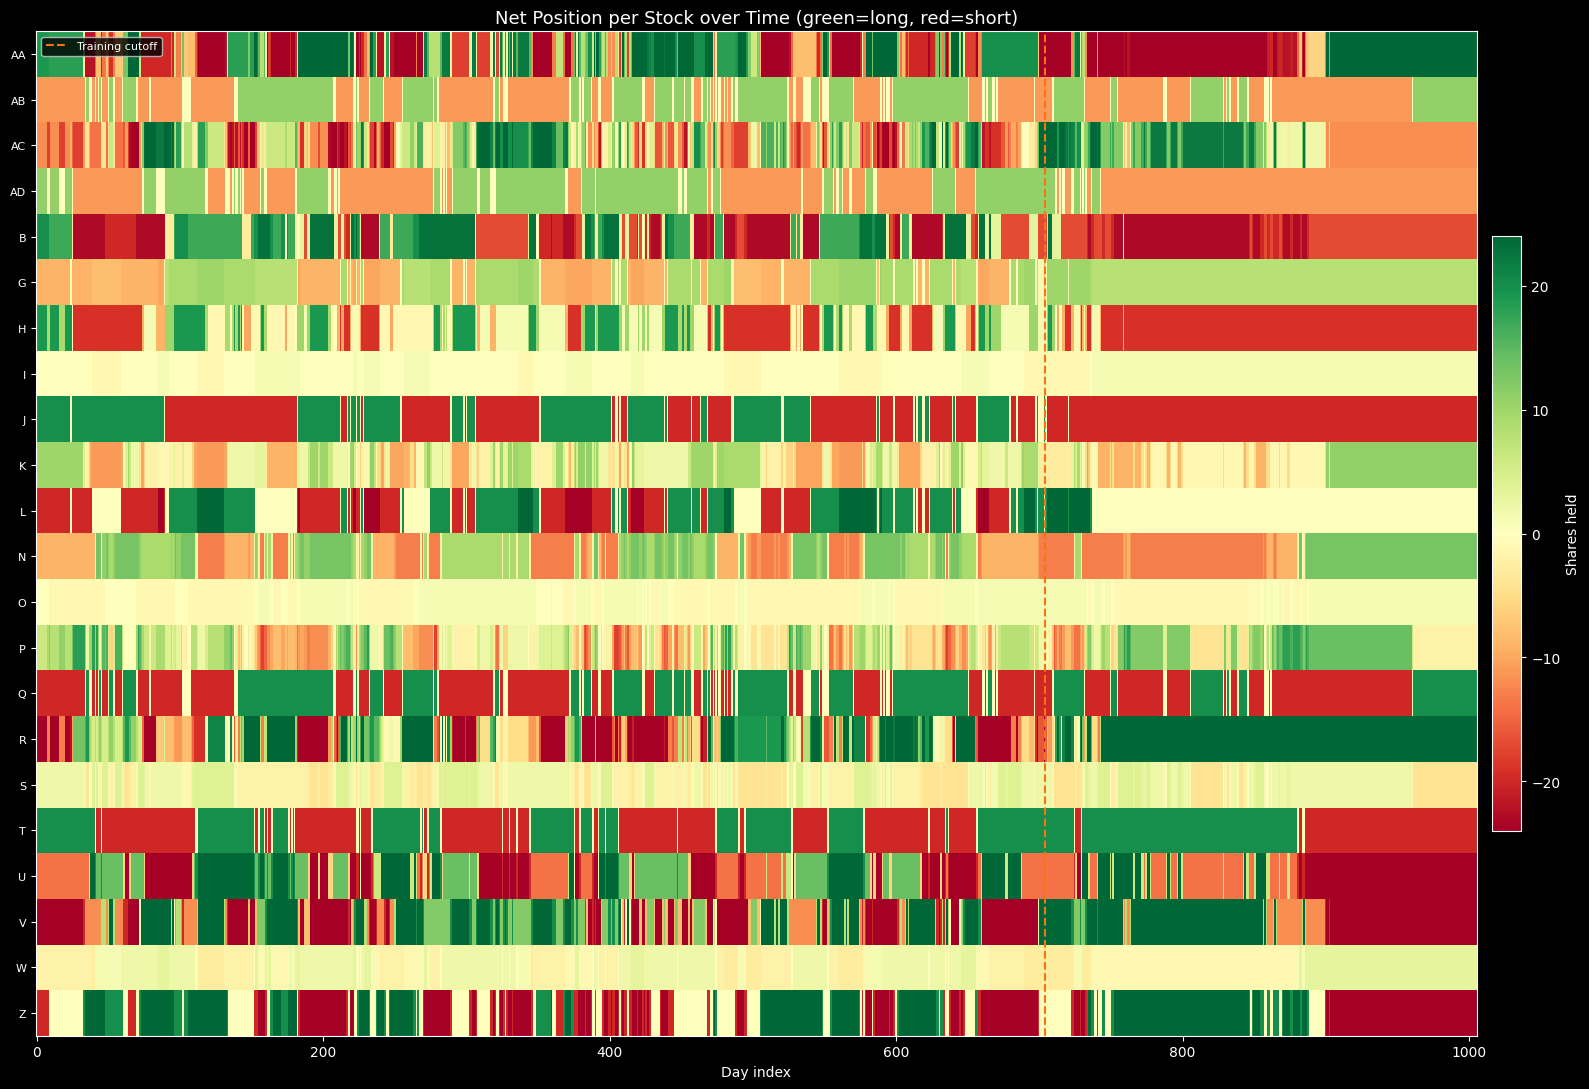


Stocks traded: 22
Traded tickers: ['AA', 'AB', 'AC', 'AD', 'B', 'G', 'H', 'I', 'J', 'K', 'L', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'Z']


In [13]:
# ---------------------------------------------------------------------------
# Plot 2: Net positions over time (heatmap) — which stocks are held and when
# ---------------------------------------------------------------------------
cumulative_pos = np.cumsum(acts_etf, axis=1)  # running position per stock per day

# Only show stocks that were actually traded
traded_mask = np.any(acts_etf != 0, axis=1)
traded_idxs = np.where(traded_mask)[0]
traded_tickers = [tickers[i] for i in traded_idxs]

fig, ax = plt.subplots(figsize=(16, max(4, len(traded_tickers) * 0.5)))
im = ax.imshow(cumulative_pos[traded_idxs], aspect='auto', cmap='RdYlGn',
               vmin=-MAX_POS * 1.2, vmax=MAX_POS * 1.2, interpolation='nearest')
ax.set_yticks(range(len(traded_tickers)))
ax.set_yticklabels(traded_tickers, fontsize=8)
ax.set_title('Net Position per Stock over Time (green=long, red=short)', fontsize=13)
ax.set_xlabel('Day index')

# Mark training cutoff
ax.axvline(train_end, color='#f97316', linewidth=1.5, linestyle='--', label='Training cutoff')
ax.legend(fontsize=8, loc='upper left')

plt.colorbar(im, ax=ax, label='Shares held', fraction=0.02, pad=0.01)
plt.tight_layout()
plt.show()

print(f"\nStocks traded: {len(traded_tickers)}")
print(f"Traded tickers: {traded_tickers}")

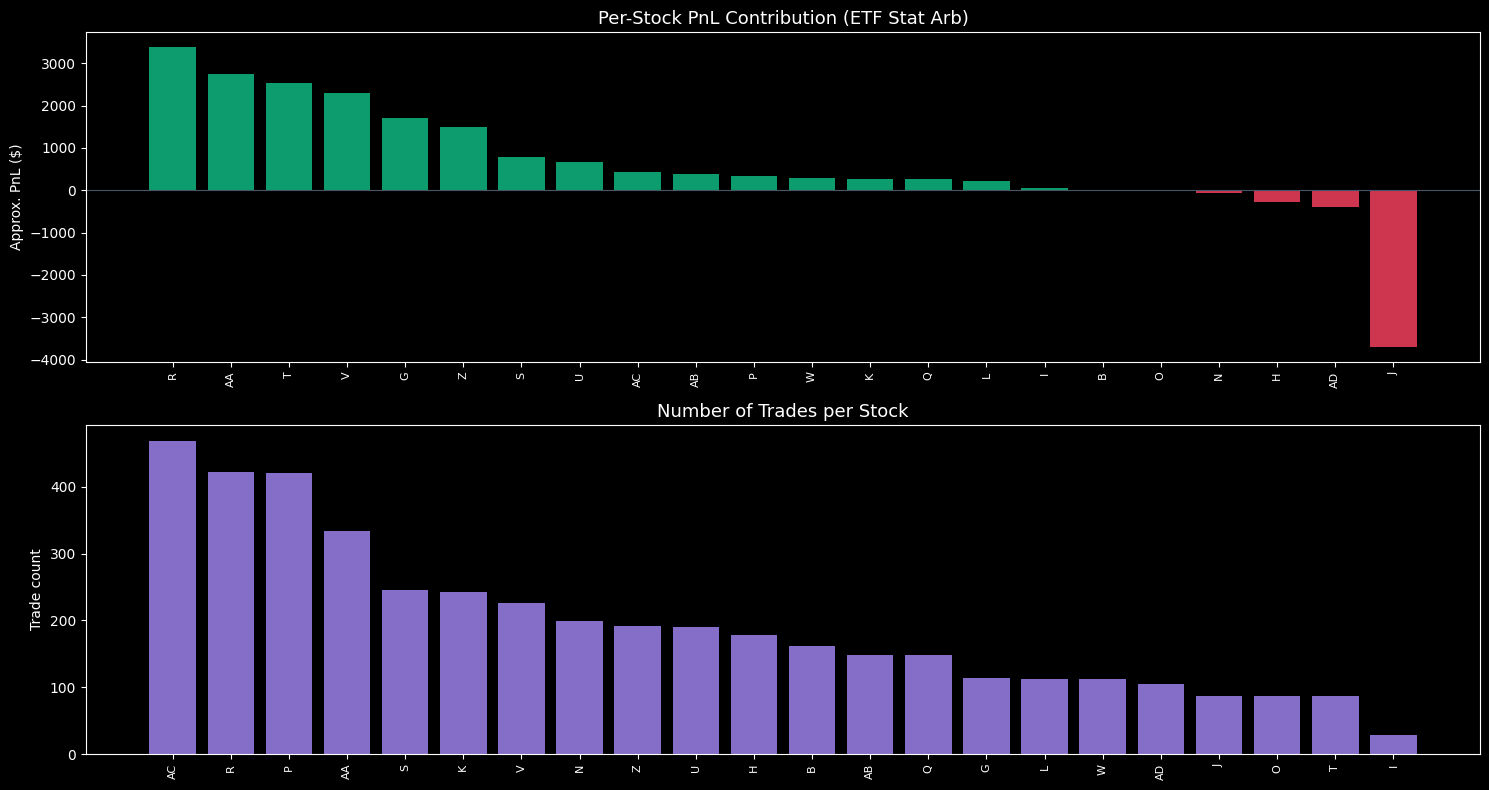

In [14]:
# ---------------------------------------------------------------------------
# Plot 3: Per-stock PnL contribution & trade activity
# ---------------------------------------------------------------------------
# Approximate per-stock PnL: cash flows from trades + mark-to-market of final position
acts_rounded = np.round(acts_etf).astype(int)
trade_cashflow = np.zeros(len(tickers))
for s in range(len(tickers)):
    trade_cashflow[s] = -np.sum(acts_rounded[s] * prices[s])

final_position = acts_rounded.sum(axis=1)
mtm = final_position * prices[:, -1]
approx_pnl_stock = trade_cashflow + mtm

pnl_stock_df = pd.Series(approx_pnl_stock, index=tickers).sort_values(ascending=False)
# Filter to only traded stocks
pnl_stock_df = pnl_stock_df[pnl_stock_df.index.isin(traded_tickers)]

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Per-stock PnL bar chart
colors = ['#10b981' if v >= 0 else '#f43f5e' for v in pnl_stock_df.values]
axes[0].bar(pnl_stock_df.index, pnl_stock_df.values, color=colors, alpha=0.85)
axes[0].axhline(0, color='#475569', linewidth=0.8)
axes[0].set_title('Per-Stock PnL Contribution (ETF Stat Arb)', fontsize=13)
axes[0].set_ylabel('Approx. PnL ($)')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)

# Trade count per stock
trade_counts = pd.Series(
    {tickers[i]: np.count_nonzero(acts_etf[i]) for i in traded_idxs}
).sort_values(ascending=False)
axes[1].bar(trade_counts.index, trade_counts.values, color='#a78bfa', alpha=0.8)
axes[1].set_title('Number of Trades per Stock', fontsize=13)
axes[1].set_ylabel('Trade count')
axes[1].tick_params(axis='x', rotation=90, labelsize=8)

plt.tight_layout()
plt.show()

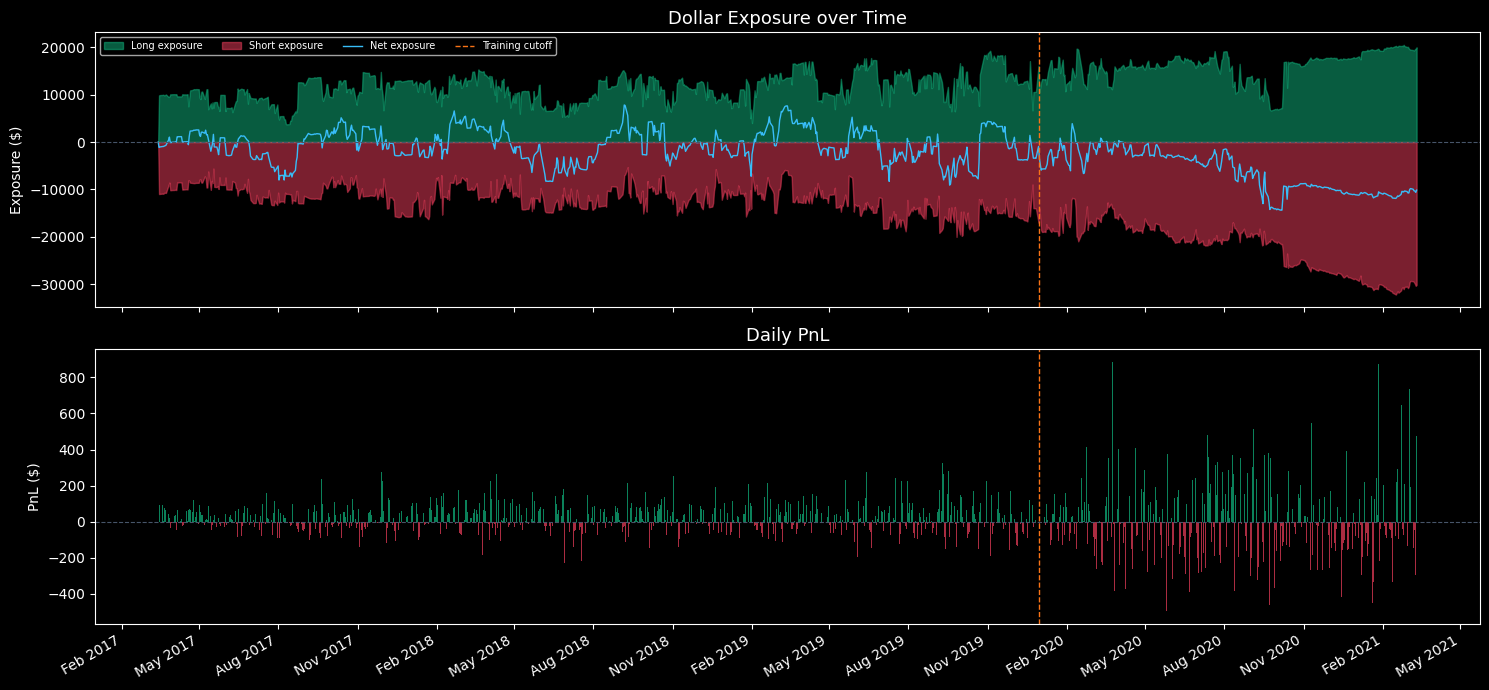


Post-training trading days: 302
Winning days: 133 (44.0%)
Losing days:  169 (56.0%)
Flat days:    0
Avg daily PnL (trading period): $-4.79
Sharpe (annualized, trading period): -0.36


In [15]:
# ---------------------------------------------------------------------------
# Plot 4: Daily net exposure & trade markers on timeline
# ---------------------------------------------------------------------------
# Total dollar exposure per day
long_exposure = np.zeros(len(dates))
short_exposure = np.zeros(len(dates))
for d in range(len(dates)):
    for s in range(len(tickers)):
        pos = cumulative_pos[s, d]
        dollar_val = pos * prices[s, d]
        if dollar_val > 0:
            long_exposure[d] += dollar_val
        else:
            short_exposure[d] += dollar_val

# Days where trades happened
trade_days = np.where(np.any(acts_etf != 0, axis=0))[0]

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# Dollar exposure
axes[0].fill_between(dates, long_exposure, color='#10b981', alpha=0.5, label='Long exposure')
axes[0].fill_between(dates, short_exposure, color='#f43f5e', alpha=0.5, label='Short exposure')
axes[0].plot(dates, long_exposure + short_exposure, color='#38bdf8', linewidth=1, label='Net exposure')
axes[0].axhline(0, color='#475569', linewidth=0.8, linestyle='--')
axes[0].axvline(dates[train_end], color='#f97316', linewidth=1, linestyle='--', label='Training cutoff')
axes[0].set_title('Dollar Exposure over Time', fontsize=13)
axes[0].set_ylabel('Exposure ($)')
axes[0].legend(fontsize=7, ncol=4)

# Daily PnL (change in portfolio value)
daily_pnl = np.diff(pv_etf, prepend=25_000)
pos_days = daily_pnl >= 0
axes[1].bar(dates[pos_days], daily_pnl[pos_days], color='#10b981', alpha=0.7, width=1)
axes[1].bar(dates[~pos_days], daily_pnl[~pos_days], color='#f43f5e', alpha=0.7, width=1)
axes[1].axhline(0, color='#475569', linewidth=0.8, linestyle='--')
axes[1].axvline(dates[train_end], color='#f97316', linewidth=1, linestyle='--')
axes[1].set_title('Daily PnL', fontsize=13)
axes[1].set_ylabel('PnL ($)')
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

# Summary stats
winning_days = np.sum(daily_pnl[train_end:] > 0)
losing_days = np.sum(daily_pnl[train_end:] < 0)
flat_days = np.sum(daily_pnl[train_end:] == 0)
trading_days = len(dates) - train_end
print(f"\nPost-training trading days: {trading_days}")
print(f"Winning days: {winning_days} ({100*winning_days/trading_days:.1f}%)")
print(f"Losing days:  {losing_days} ({100*losing_days/trading_days:.1f}%)")
print(f"Flat days:    {flat_days}")
print(f"Avg daily PnL (trading period): ${np.mean(daily_pnl[train_end:]):.2f}")
print(f"Sharpe (annualized, trading period): {np.mean(daily_pnl[train_end:]) / (np.std(daily_pnl[train_end:]) + 1e-10) * np.sqrt(252):.2f}")

## 10. Returns-Based vs Adaptive Thresholds — Comparison

Two regime-adaptive variants of the ETF stat arb strategy, now trained through the COVID crash (`train_frac=0.85`, split at 2020-08-06):

1. **Returns-based** (`strategy_etf_arb_returns.py`): OLS on cumulative log returns. Best params: `entry_threshold=0.02, max_position=20, r2_cutoff=0.80, train_frac=0.85`.

2. **Adaptive thresholds** (`strategy_etf_arb_adaptive.py`): Scales thresholds by `k × rolling_std(spread)`. Best params: `k_entry=1.0, k_exit=0.1, vol_window=40, max_position=20, train_frac=0.85`.

Training through COVID (0.85 split) vs stopping before it (0.70 split) dramatically improves post-2020 performance because the OLS weights learn the new price regime.

In [16]:
import importlib
import strategy_etf_arb_returns, strategy_etf_arb_adaptive
importlib.reload(strategy_etf_arb_returns)
importlib.reload(strategy_etf_arb_adaptive)
from strategy_etf_arb_returns import get_actions as get_actions_returns
from strategy_etf_arb_adaptive import get_actions as get_actions_adaptive

TRAIN_FRAC = 0.85  # train through COVID crash (split at 2020-08-06)

# --- Returns-based (best params) ---
acts_ret = get_actions_returns(prices, entry_threshold=0.02, max_position=20,
                                r2_cutoff=0.80, train_frac=TRAIN_FRAC)
bt_ret = Backtester(prices, acts_ret)
pv_ret, pnl_ret = bt_ret.eval_actions()
pv_ret = np.array(pv_ret)
fees_ret = np.sum(np.abs(acts_ret) * prices * 0.001)

# --- Adaptive thresholds (best params) ---
acts_adp = get_actions_adaptive(prices, k_entry=1.0, k_exit=0.1, vol_window=40,
                                 max_position=20, train_frac=TRAIN_FRAC)
bt_adp = Backtester(prices, acts_adp)
pv_adp, pnl_adp = bt_adp.eval_actions()
pv_adp = np.array(pv_adp)
fees_adp = np.sum(np.abs(acts_adp) * prices * 0.001)

train_end = int(len(dates) * TRAIN_FRAC)

for name, pnl, fees, pv in [('Returns-based', pnl_ret, fees_ret, pv_ret),
                              ('Adaptive', pnl_adp, fees_adp, pv_adp)]:
    daily = np.diff(pv)
    sharpe = np.mean(daily) / np.std(daily) * np.sqrt(252) if np.std(daily) > 0 else 0
    running_max = np.maximum.accumulate(pv)
    max_dd = np.max((running_max - pv) / running_max)
    print(f"{name:16s}  Raw PnL: ${pnl:>10,.2f}  Fees: ${fees:>8,.2f}  Net: ${pnl - fees:>10,.2f}  "
          f"Sharpe: {sharpe:.2f}  MaxDD: {max_dd:.1%}")

Final portfolio value: 43971.07
PnL: 18971.07
Final portfolio value: 49757.76
PnL: 24757.76
Returns-based     Raw PnL: $ 18,971.07  Fees: $2,683.69  Net: $ 16,287.38  Sharpe: 2.08  MaxDD: 4.8%
Adaptive          Raw PnL: $ 24,757.76  Fees: $2,298.37  Net: $ 22,459.39  Sharpe: 2.94  MaxDD: 3.4%


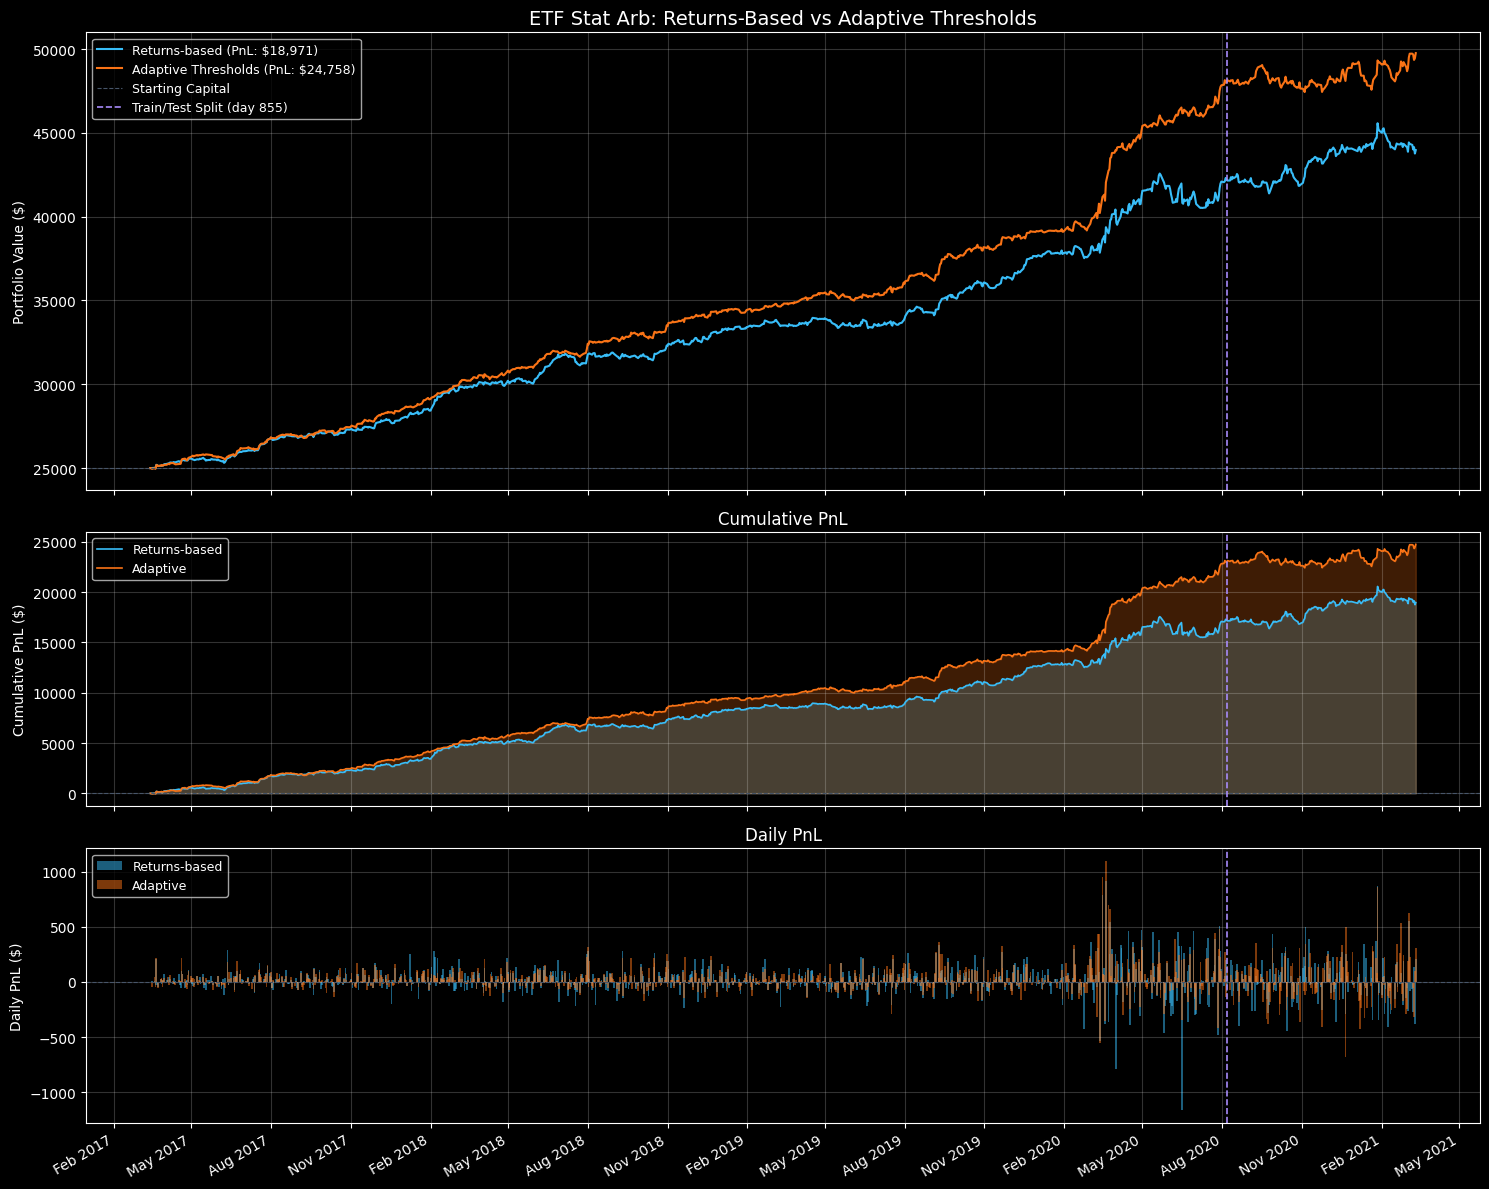

In [17]:
# ---------------------------------------------------------------------------
# Plot 1: Portfolio value comparison
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1.2, 1.2]})

# --- Top: Portfolio value ---
axes[0].plot(dates, pv_ret, color='#38bdf8', linewidth=1.5,
             label=f'Returns-based (PnL: ${pnl_ret:,.0f})')
axes[0].plot(dates, pv_adp, color='#f97316', linewidth=1.5,
             label=f'Adaptive Thresholds (PnL: ${pnl_adp:,.0f})')
axes[0].axhline(25_000, color='#475569', linewidth=0.8, linestyle='--', label='Starting Capital')
axes[0].axvline(dates[train_end], color='#a78bfa', linewidth=1.2, linestyle='--',
                label=f'Train/Test Split (day {train_end})')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].set_title('ETF Stat Arb: Returns-Based vs Adaptive Thresholds', fontsize=14)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.2)

# --- Middle: Cumulative PnL ---
pnl_curve_ret = pv_ret - 25_000
pnl_curve_adp = pv_adp - 25_000
axes[1].fill_between(dates, pnl_curve_ret, alpha=0.25, color='#38bdf8')
axes[1].fill_between(dates, pnl_curve_adp, alpha=0.25, color='#f97316')
axes[1].plot(dates, pnl_curve_ret, color='#38bdf8', linewidth=1.2, label='Returns-based')
axes[1].plot(dates, pnl_curve_adp, color='#f97316', linewidth=1.2, label='Adaptive')
axes[1].axhline(0, color='#475569', linewidth=0.8, linestyle='--')
axes[1].axvline(dates[train_end], color='#a78bfa', linewidth=1.2, linestyle='--')
axes[1].set_ylabel('Cumulative PnL ($)')
axes[1].set_title('Cumulative PnL', fontsize=12)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.2)

# --- Bottom: Daily PnL bars ---
daily_ret = np.diff(pv_ret, prepend=25_000)
daily_adp = np.diff(pv_adp, prepend=25_000)
axes[2].bar(dates, daily_ret, alpha=0.5, color='#38bdf8', width=2, label='Returns-based')
axes[2].bar(dates, daily_adp, alpha=0.5, color='#f97316', width=2, label='Adaptive')
axes[2].axhline(0, color='#475569', linewidth=0.8, linestyle='--')
axes[2].axvline(dates[train_end], color='#a78bfa', linewidth=1.2, linestyle='--')
axes[2].set_ylabel('Daily PnL ($)')
axes[2].set_title('Daily PnL', fontsize=12)
axes[2].legend(loc='upper left', fontsize=9)
axes[2].grid(True, alpha=0.2)
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

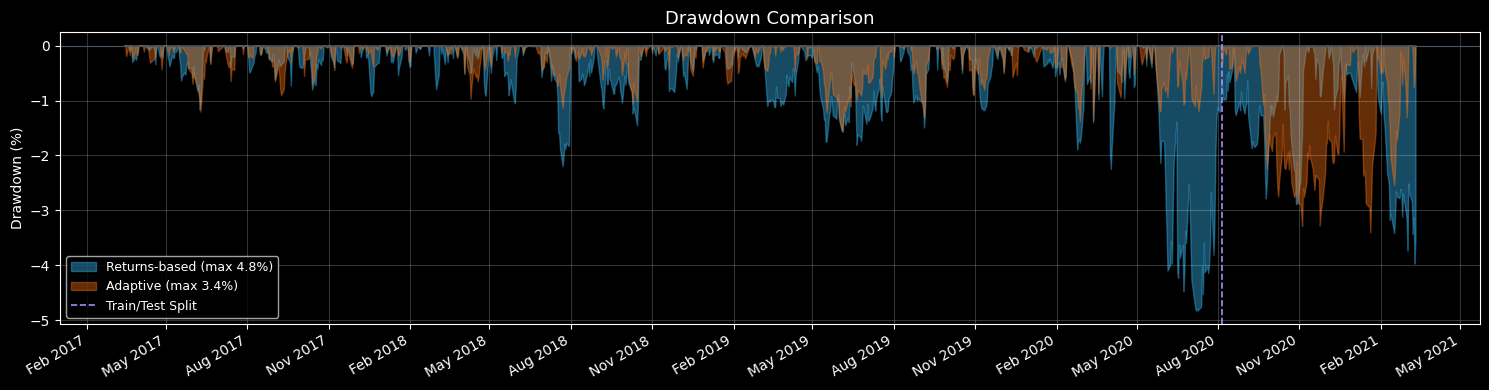

In [18]:
# ---------------------------------------------------------------------------
# Plot 2: Drawdown comparison
# ---------------------------------------------------------------------------
def compute_drawdown(pv):
    running_max = np.maximum.accumulate(pv)
    return (running_max - pv) / running_max

dd_ret = compute_drawdown(pv_ret)
dd_adp = compute_drawdown(pv_adp)

fig, ax = plt.subplots(figsize=(15, 4))
ax.fill_between(dates, -dd_ret * 100, alpha=0.4, color='#38bdf8', label=f'Returns-based (max {dd_ret.max():.1%})')
ax.fill_between(dates, -dd_adp * 100, alpha=0.4, color='#f97316', label=f'Adaptive (max {dd_adp.max():.1%})')
ax.axhline(0, color='#475569', linewidth=0.8)
ax.axvline(dates[train_end], color='#a78bfa', linewidth=1.2, linestyle='--', label='Train/Test Split')
ax.set_ylabel('Drawdown (%)')
ax.set_title('Drawdown Comparison', fontsize=13)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

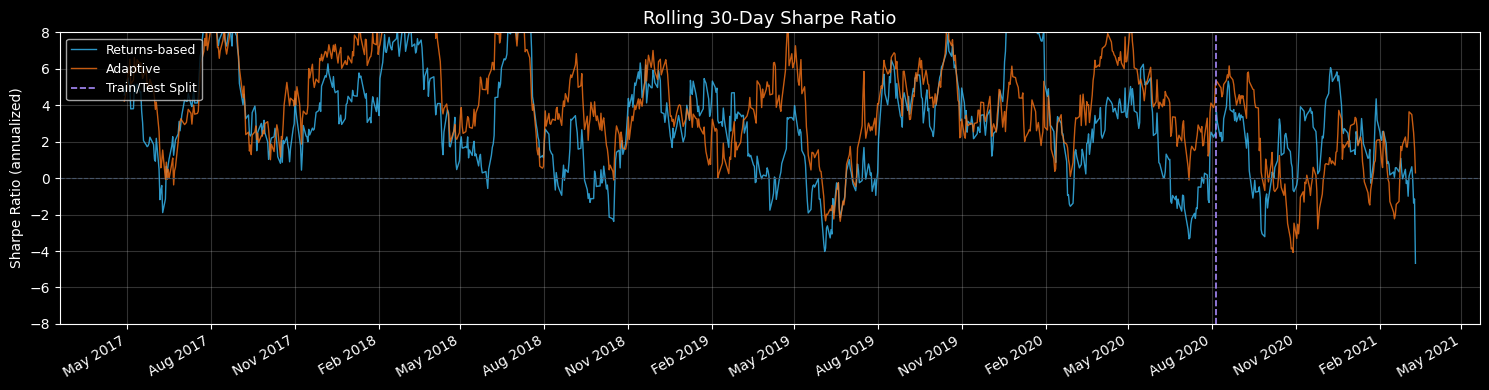

In [19]:
# ---------------------------------------------------------------------------
# Plot 3: Rolling 30-day Sharpe ratio comparison
# ---------------------------------------------------------------------------
window = 30

daily_pnl_ret = np.diff(pv_ret)
daily_pnl_adp = np.diff(pv_adp)

rolling_sharpe_ret = np.full(len(daily_pnl_ret), np.nan)
rolling_sharpe_adp = np.full(len(daily_pnl_adp), np.nan)

for i in range(window, len(daily_pnl_ret)):
    w_ret = daily_pnl_ret[i-window:i]
    w_adp = daily_pnl_adp[i-window:i]
    rolling_sharpe_ret[i] = np.mean(w_ret) / (np.std(w_ret) + 1e-10) * np.sqrt(252)
    rolling_sharpe_adp[i] = np.mean(w_adp) / (np.std(w_adp) + 1e-10) * np.sqrt(252)

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(dates[1:], rolling_sharpe_ret, color='#38bdf8', linewidth=1, alpha=0.8, label='Returns-based')
ax.plot(dates[1:], rolling_sharpe_adp, color='#f97316', linewidth=1, alpha=0.8, label='Adaptive')
ax.axhline(0, color='#475569', linewidth=0.8, linestyle='--')
ax.axvline(dates[train_end], color='#a78bfa', linewidth=1.2, linestyle='--', label='Train/Test Split')
ax.set_ylabel('Sharpe Ratio (annualized)')
ax.set_title(f'Rolling {window}-Day Sharpe Ratio', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(-8, 8)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Final portfolio value: 68728.83
PnL: 43728.83


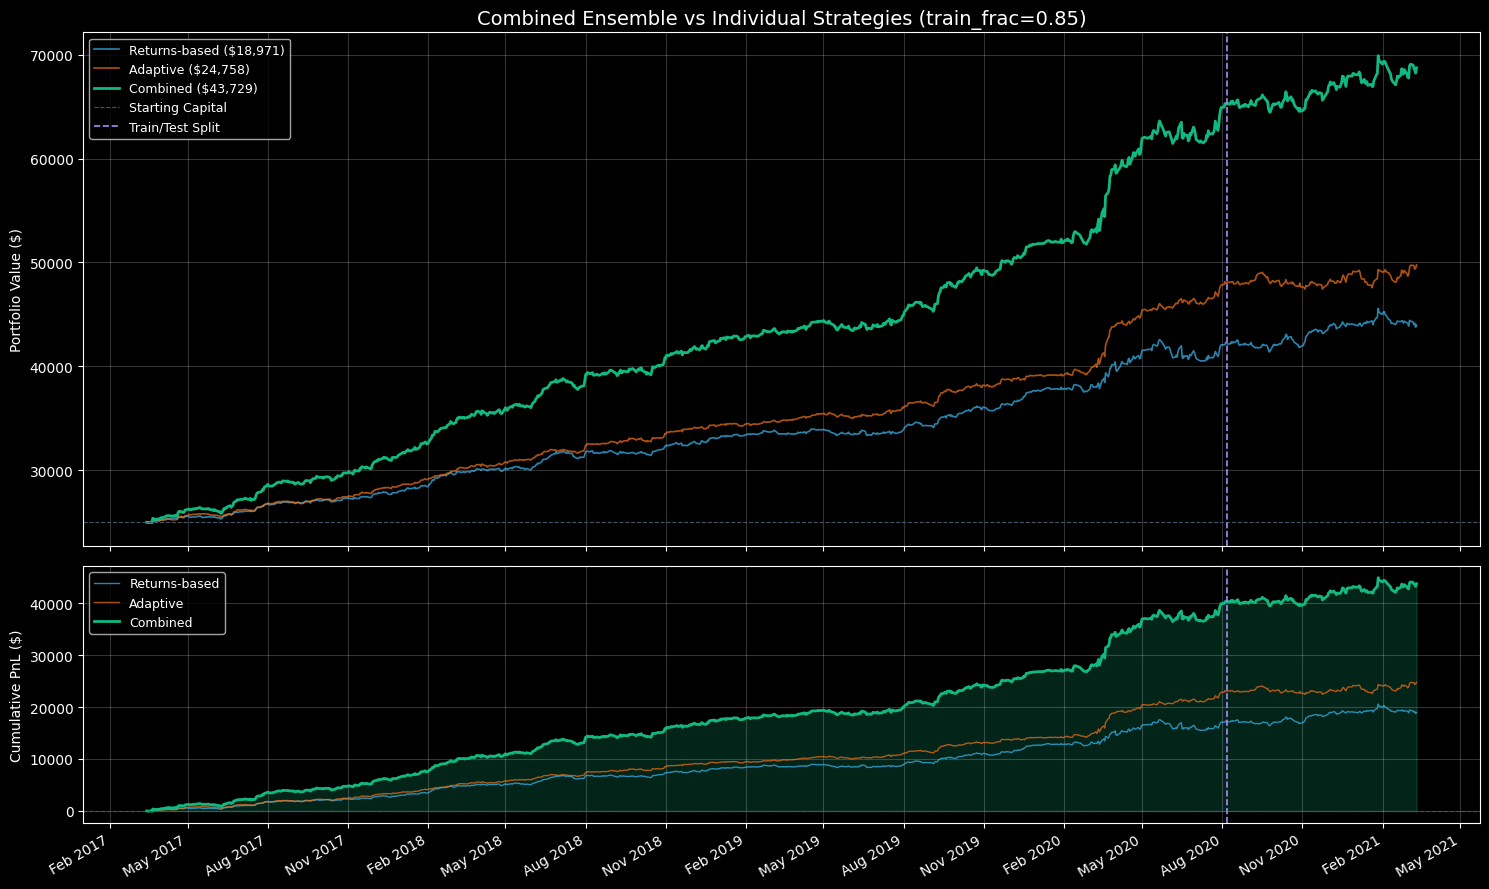


Strategy                    PnL   Sharpe    MaxDD
------------------------------------------------
Returns-based        $   18,971     2.08    4.8%
Adaptive             $   24,758     2.94    3.4%
Combined             $   43,729     2.75    4.0%


In [20]:
# ---------------------------------------------------------------------------
# Plot 4: Combined ensemble vs individual strategies
# ---------------------------------------------------------------------------
from strategy_combined import get_actions as get_actions_combined

acts_comb = get_actions_combined(prices, train_frac=TRAIN_FRAC)
bt_comb = Backtester(prices, acts_comb)
pv_comb, pnl_comb = bt_comb.eval_actions()
pv_comb = np.array(pv_comb)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

# Portfolio value
axes[0].plot(dates, pv_ret, color='#38bdf8', linewidth=1.2, alpha=0.7, label=f'Returns-based (${pnl_ret:,.0f})')
axes[0].plot(dates, pv_adp, color='#f97316', linewidth=1.2, alpha=0.7, label=f'Adaptive (${pnl_adp:,.0f})')
axes[0].plot(dates, pv_comb, color='#10b981', linewidth=2, label=f'Combined (${pnl_comb:,.0f})')
axes[0].axhline(25_000, color='#475569', linewidth=0.8, linestyle='--', label='Starting Capital')
axes[0].axvline(dates[train_end], color='#a78bfa', linewidth=1.2, linestyle='--', label='Train/Test Split')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].set_title('Combined Ensemble vs Individual Strategies (train_frac=0.85)', fontsize=14)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.2)

# Cumulative PnL
axes[1].fill_between(dates, pv_comb - 25_000, alpha=0.2, color='#10b981')
axes[1].plot(dates, pv_ret - 25_000, color='#38bdf8', linewidth=1, alpha=0.7, label='Returns-based')
axes[1].plot(dates, pv_adp - 25_000, color='#f97316', linewidth=1, alpha=0.7, label='Adaptive')
axes[1].plot(dates, pv_comb - 25_000, color='#10b981', linewidth=2, label='Combined')
axes[1].axhline(0, color='#475569', linewidth=0.8, linestyle='--')
axes[1].axvline(dates[train_end], color='#a78bfa', linewidth=1.2, linestyle='--')
axes[1].set_ylabel('Cumulative PnL ($)')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.2)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Strategy':<20s} {'PnL':>10s} {'Sharpe':>8s} {'MaxDD':>8s}")
print('-' * 48)
for name, pv in [('Returns-based', pv_ret), ('Adaptive', pv_adp), ('Combined', pv_comb)]:
    d = np.diff(pv)
    sh = np.mean(d) / np.std(d) * np.sqrt(252) if np.std(d) > 0 else 0
    dd = np.max((np.maximum.accumulate(pv) - pv) / np.maximum.accumulate(pv))
    p = pv[-1] - 25_000
    print(f'{name:<20s} ${p:>9,.0f} {sh:>8.2f} {dd:>7.1%}')

## 11. ETF Arb Tuned — Combined Improvements

The tuned strategy combines three improvements over the baseline combined ensemble:
1. **Volatility-scaled position sizing** — scales position size inversely with rolling spread vol
2. **Tighter exit thresholds** — exits before full mean reversion (exit_threshold=0.008, k_exit=0.2)
3. **Per-pair circuit breaker** — stops trading pairs with cumulative loss > $500

In [21]:
from etf_arb_tuned import get_actions as get_actions_tuned

# --- Backtest tuned strategy ---
acts_tuned = get_actions_tuned(prices)
bt_tuned = Backtester(prices, acts_tuned, cash=25_000)
pv_tuned, pnl_tuned = bt_tuned.eval_actions()
pv_tuned = np.array(pv_tuned)

# --- Backtest baseline for comparison ---
acts_base = get_actions_combined(prices, train_frac=0.85)
bt_base = Backtester(prices, acts_base, cash=25_000)
pv_base, pnl_base = bt_base.eval_actions()
pv_base = np.array(pv_base)

# --- Metrics ---
def calc_metrics(pv):
    daily = np.diff(pv)
    sharpe = np.mean(daily) / (np.std(daily) + 1e-10) * np.sqrt(252)
    running_max = np.maximum.accumulate(pv)
    max_dd = np.max((running_max - pv) / running_max)
    return sharpe, max_dd

sharpe_tuned, dd_tuned = calc_metrics(pv_tuned)
sharpe_base, dd_base = calc_metrics(pv_base)

print(f"{'Strategy':<25s} {'PnL':>10s} {'Sharpe':>8s} {'MaxDD':>8s}")
print('-' * 53)
print(f"{'Baseline Combined':<25s} ${pnl_base:>9,.0f} {sharpe_base:>8.2f} {dd_base:>7.1%}")
print(f"{'Tuned (vol+exit+circuit)':<25s} ${pnl_tuned:>9,.0f} {sharpe_tuned:>8.2f} {dd_tuned:>7.1%}")

Final portfolio value: 72837.93
PnL: 47837.93
Final portfolio value: 68728.83
PnL: 43728.83
Strategy                         PnL   Sharpe    MaxDD
-----------------------------------------------------
Baseline Combined         $   43,729     2.75    4.0%
Tuned (vol+exit+circuit)  $   47,838     3.13    3.2%


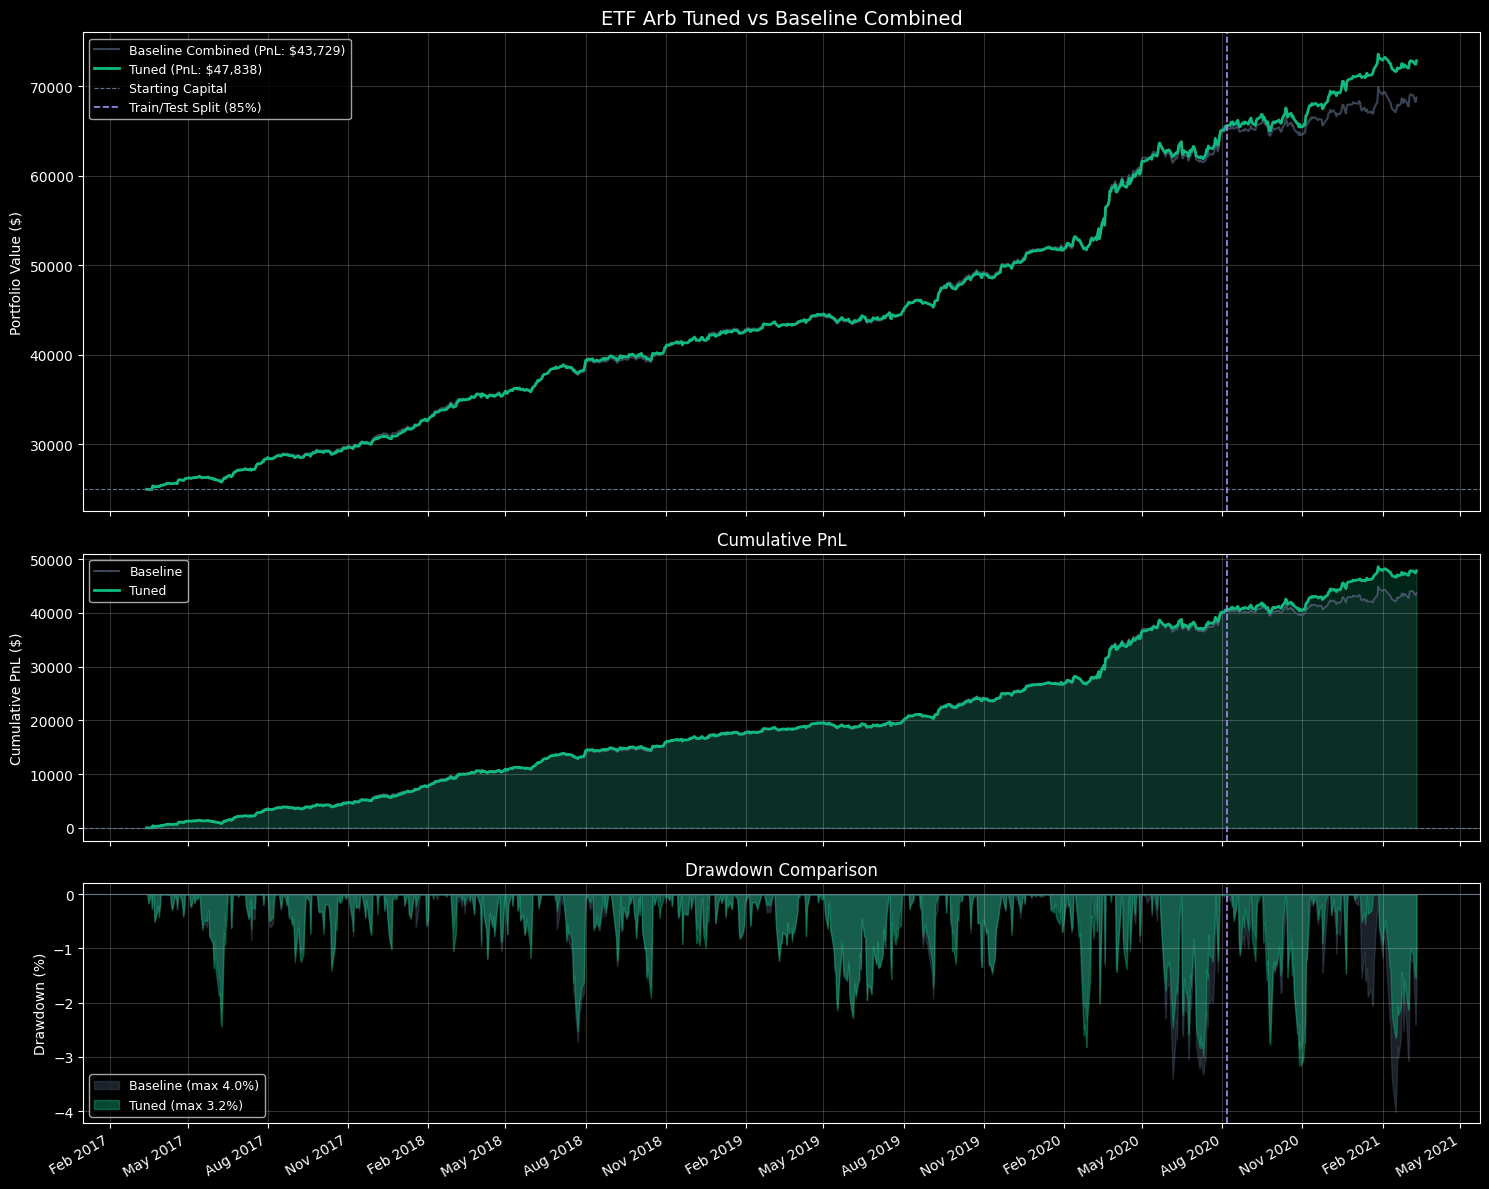

In [22]:
# ---------------------------------------------------------------------------
# Plot: Tuned vs Baseline — Portfolio Value, Cumulative PnL, Drawdown
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1.2, 1]})

train_end_idx = int(len(dates) * 0.85)

# --- Portfolio Value ---
axes[0].plot(dates, pv_base, color='#475569', linewidth=1.5, alpha=0.8,
             label=f'Baseline Combined (PnL: ${pnl_base:,.0f})')
axes[0].plot(dates, pv_tuned, color='#10b981', linewidth=2,
             label=f'Tuned (PnL: ${pnl_tuned:,.0f})')
axes[0].axhline(25_000, color='#64748b', linewidth=0.8, linestyle='--', label='Starting Capital')
axes[0].axvline(dates[train_end_idx], color='#a78bfa', linewidth=1.2, linestyle='--', label='Train/Test Split (85%)')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].set_title('ETF Arb Tuned vs Baseline Combined', fontsize=14)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.2)

# --- Cumulative PnL ---
pnl_curve_base = pv_base - 25_000
pnl_curve_tuned = pv_tuned - 25_000
axes[1].fill_between(dates, pnl_curve_base, alpha=0.15, color='#475569')
axes[1].fill_between(dates, pnl_curve_tuned, alpha=0.2, color='#10b981')
axes[1].plot(dates, pnl_curve_base, color='#475569', linewidth=1.2, label='Baseline')
axes[1].plot(dates, pnl_curve_tuned, color='#10b981', linewidth=2, label='Tuned')
axes[1].axhline(0, color='#64748b', linewidth=0.8, linestyle='--')
axes[1].axvline(dates[train_end_idx], color='#a78bfa', linewidth=1.2, linestyle='--')
axes[1].set_ylabel('Cumulative PnL ($)')
axes[1].set_title('Cumulative PnL', fontsize=12)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.2)

# --- Drawdown ---
def compute_drawdown(pv):
    running_max = np.maximum.accumulate(pv)
    return (running_max - pv) / running_max

dd_base_curve = compute_drawdown(pv_base)
dd_tuned_curve = compute_drawdown(pv_tuned)

axes[2].fill_between(dates, -dd_base_curve * 100, alpha=0.4, color='#475569',
                     label=f'Baseline (max {dd_base_curve.max():.1%})')
axes[2].fill_between(dates, -dd_tuned_curve * 100, alpha=0.4, color='#10b981',
                     label=f'Tuned (max {dd_tuned_curve.max():.1%})')
axes[2].axhline(0, color='#64748b', linewidth=0.8)
axes[2].axvline(dates[train_end_idx], color='#a78bfa', linewidth=1.2, linestyle='--')
axes[2].set_ylabel('Drawdown (%)')
axes[2].set_title('Drawdown Comparison', fontsize=12)
axes[2].legend(loc='lower left', fontsize=9)
axes[2].grid(True, alpha=0.2)
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()